### Task 2: Apply dimension reduction techniques

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import time
import os
import warnings

from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

warnings.filterwarnings("ignore")

np.random.seed(42)

### Load Data

In [3]:
def load_raw_text():
    data_dir = "../../data"
    train_df = pd.read_csv(f"{data_dir}/train_abstracts.csv")
    test_df = pd.read_csv(f"{data_dir}/test_abstracts.csv")
    labels_df = pd.read_csv(f"{data_dir}/train_labels.csv")
    ids_df = pd.read_csv(f"{data_dir}/test_ids.csv")

    train_texts = train_df["abstract"].values
    test_texts = test_df["abstract"].values
    y_train = labels_df["label_id"].values
    test_ids = ids_df["id"].values

    print(f"Training samples: {len(train_texts)}")
    print(f"Test samples: {len(test_texts)}")

    return train_texts, test_texts, y_train, test_ids


train_texts, test_texts, y_train, test_ids = load_raw_text()

Training samples: 139156
Test samples: 34790


### Helper Functions

In [4]:
# Convert raw text into tf-idf matrix
def compute_tfidf(train_texts, test_texts, max_features=None):
    print(f"\nComputing TF-IDF with max_features={max_features}...")
    start_time = time.time()

    vectorizer = TfidfVectorizer(
        max_features=max_features,
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 1),
        max_df=0.95,
        min_df=2,
        sublinear_tf=True,
    )

    X_train = vectorizer.fit_transform(train_texts)
    X_test = vectorizer.transform(test_texts)

    elapsed = time.time() - start_time
    print(f"Completed in {elapsed:.2f} seconds")
    print(f"Training shape: {X_train.shape}")
    print(f"Test shape: {X_test.shape}")

    return X_train, X_test, vectorizer


# Reduce dimensions using PCA (TruncatedSVD for sparse data)
def apply_pca(X_train, X_test, n_components):
    print(f"\nApplying PCA with {n_components} components...")
    start_time = time.time()

    pca = TruncatedSVD(n_components=n_components, random_state=42, n_iter=7)

    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    explained_variance = pca.explained_variance_ratio_.sum()

    elapsed = time.time() - start_time
    print(f"Completed in {elapsed:.2f} seconds")
    print(f"Training shape: {X_train_pca.shape}")
    print(f"Explained variance: {explained_variance:.2%}")

    return X_train_pca, X_test_pca, pca


# Train KNN classifier
def train_knn(X_train, y_train, n_neighbors=2):
    print(f"\nTraining KNN with n_neighbors={n_neighbors}...")
    start_time = time.time()

    knn = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        metric="euclidean",  # Euclidean distance metric
        n_jobs=-1,  # use all available CPU cores for parallel processing
    )

    knn.fit(X_train, y_train)

    elapsed = time.time() - start_time
    print(f"Completed in {elapsed:.2f} seconds")

    return knn


# Saves predictions to CSV file for submission format
def create_submission(test_ids, predictions, method_name, n_features):
    submission_df = pd.DataFrame({"id": test_ids, "label_id": predictions})

    filename = f"../../submissions/Task2_{method_name}_{n_features}.csv"
    submission_df.to_csv(filename, index=False)
    print(f"\nSubmission saved: {filename}")

    return submission_df

### Feature Selection
Re-computing the TF-IDF matrix while restricting the vocabulary to the top N most frequent words to reduce dimensionality.

In [5]:
def run_feature_selection(train_texts, test_texts, y_train, test_ids):
    feature_sizes = [2000, 1000, 500, 100]
    results = {}

    for n in feature_sizes:
        print(f"\n{'=' * 50}")
        print(f"Testing with {n} features")
        print(f"{'=' * 50}")

        # Re-fit TF-IDF keeping only the top n words
        X_train_fs, X_test_fs, vectorizer = compute_tfidf(
            train_texts, test_texts, max_features=n
        )

        # Train KNN and get predictions
        knn = train_knn(X_train_fs, y_train, n_neighbors=2)
        predictions = knn.predict(X_test_fs)

        # Save submission CSV for Kaggle
        os.makedirs("../../submissions", exist_ok=True)
        submission = create_submission(test_ids, predictions, "fs", n)

        results[n] = {
            "predictions": predictions,
            "submission": submission,
            "model": knn,
            "vectorizer": vectorizer,
            "X_train": X_train_fs,
            "X_test": X_test_fs,
        }

    return results


print("=" * 55)
print("EXPERIMENT 1: Feature Selection")
print("=" * 55)
fs_results = run_feature_selection(train_texts, test_texts, y_train, test_ids)
print("\nFeature selection experiments complete.")

EXPERIMENT 1: Feature Selection

Testing with 2000 features

Computing TF-IDF with max_features=2000...
Completed in 13.89 seconds
Training shape: (139156, 2000)
Test shape: (34790, 2000)

Training KNN with n_neighbors=2...
Completed in 0.05 seconds

Submission saved: ../../submissions/Task2_fs_2000.csv

Testing with 1000 features

Computing TF-IDF with max_features=1000...
Completed in 13.22 seconds
Training shape: (139156, 1000)
Test shape: (34790, 1000)

Training KNN with n_neighbors=2...
Completed in 0.03 seconds

Submission saved: ../../submissions/Task2_fs_1000.csv

Testing with 500 features

Computing TF-IDF with max_features=500...
Completed in 13.15 seconds
Training shape: (139156, 500)
Test shape: (34790, 500)

Training KNN with n_neighbors=2...
Completed in 0.02 seconds

Submission saved: ../../submissions/Task2_fs_500.csv

Testing with 100 features

Computing TF-IDF with max_features=100...
Completed in 12.06 seconds
Training shape: (139156, 100)
Test shape: (34790, 100)

T

### Dimension Reduction
Build full 5000 TF-IDF features then applying TruncatedSVD (spare equivalent of PCA)to compress it down to N components/

Instead of fitting PCA 4 times, we fit it once at the maximum size and then slice it down for faster computation.

In [6]:
def run_pca_experiments(train_texts, test_texts, y_train, test_ids):
    # Build full 5000-feature TF-IDF matrix first
    print("Building full TF-IDF matrix (5000 features)...")
    X_train_full, X_test_full, full_vectorizer = compute_tfidf(
        train_texts, test_texts, max_features=5000
    )

    # L2-normalise before applying PCA
    # ensures all documents are on the same scale to improve PCA quality
    X_train_norm = normalize(X_train_full)
    X_test_norm = normalize(X_test_full)

    # fit TruncatedSVD once at the largest component count (2000)
    # then slice down for smaller sizes to avoid redundant re-fitting
    print("\nFitting TruncatedSVD (2000 components) on training data...")
    start = time.time()
    pca = TruncatedSVD(n_components=2000, random_state=42, n_iter=7)
    X_train_pca_full = pca.fit_transform(X_train_norm)
    X_test_pca_full = pca.transform(X_test_norm)
    print(
        f"Done in {time.time() - start:.1f}s. Total explained variance: {pca.explained_variance_ratio_.sum():.2%}"
    )

    component_counts = [2000, 1000, 500, 100]
    results = {}

    for n in component_counts:
        print(f"\n{'=' * 50}")
        print(f"Testing with {n} PCA components")
        print(f"{'=' * 50}")

        # Slice the already reduced matrix to get top-n components
        X_train_pca = X_train_pca_full[:, :n]
        X_test_pca = X_test_pca_full[:, :n]

        # original variance captured by these n components
        explained_variance = pca.explained_variance_ratio_[:n].sum()
        print(f"Explained variance with {n} components: {explained_variance:.2%}")

        # Train KNN and get predictions
        knn = train_knn(X_train_pca, y_train, n_neighbors=2)
        predictions = knn.predict(X_test_pca)

        os.makedirs("../../submissions", exist_ok=True)
        submission = create_submission(test_ids, predictions, "pca", n)

        results[n] = {
            "predictions": predictions,
            "submission": submission,
            "model": knn,
            "pca": pca,
            "X_train_pca": X_train_pca,
            "X_test_pca": X_test_pca,
            "explained_variance": explained_variance,
        }

    return results, X_train_full, full_vectorizer


print("=" * 55)
print("PCA (TruncatedSVD)")
print("=" * 55)
pca_results, X_train_full, full_vectorizer = run_pca_experiments(
    train_texts, test_texts, y_train, test_ids
)
print("\nPCA experiments complete.")

EXPERIMENT 2: PCA (TruncatedSVD)
Building full TF-IDF matrix (5000 features)...

Computing TF-IDF with max_features=5000...
Completed in 13.16 seconds
Training shape: (139156, 5000)
Test shape: (34790, 5000)

Fitting TruncatedSVD (2000 components) on training data...
Done in 421.0s. Total explained variance: 73.93%

Testing with 2000 PCA components
Explained variance with 2000 components: 73.93%

Training KNN with n_neighbors=2...
Completed in 0.44 seconds

Submission saved: ../../submissions/Task2_pca_2000.csv

Testing with 1000 PCA components
Explained variance with 1000 components: 53.66%

Training KNN with n_neighbors=2...
Completed in 0.57 seconds

Submission saved: ../../submissions/Task2_pca_1000.csv

Testing with 500 PCA components
Explained variance with 500 components: 36.74%

Training KNN with n_neighbors=2...
Completed in 0.37 seconds

Submission saved: ../../submissions/Task2_pca_500.csv

Testing with 100 PCA components
Explained variance with 100 components: 14.18%

Train

### Visualisation: PCA Explained Variance
To show how much of the original information is retained as the number of PCA components increases. The 95% variance threshold is indicated by the red line.

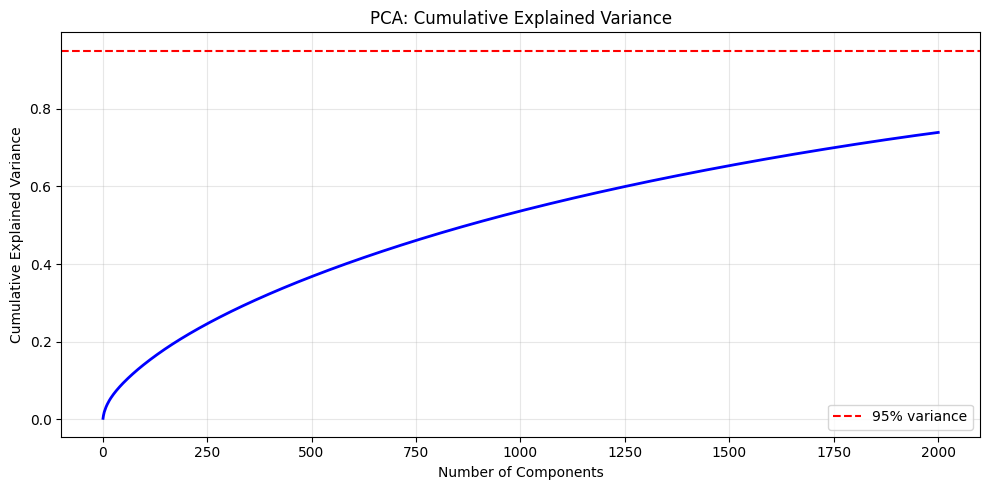

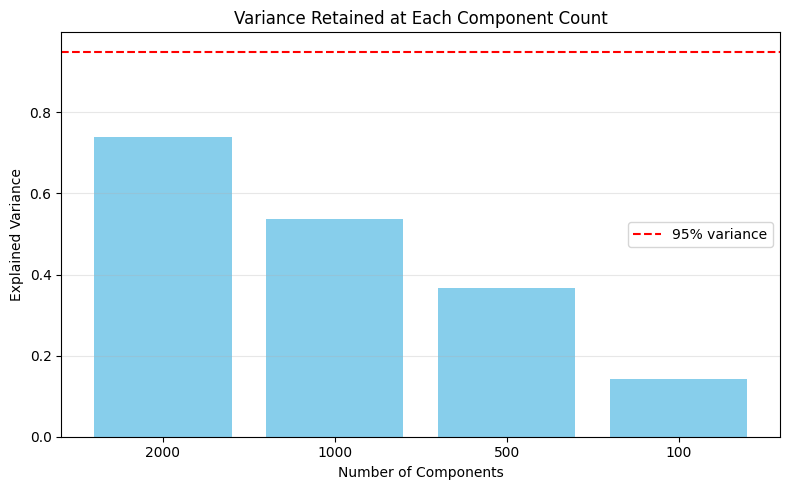


Explained variance summary:
Components      Explained Variance
-----------------------------------
2000            73.93%
1000            53.66%
500             36.74%
100             14.18%


In [9]:
def plot_cumulative_explained_variance(pca_model, component_counts):

    # Figure 1: cumulative explained variance curve across all 2000 components
    plt.figure(figsize=(10, 5))
    cumulative_variance = np.cumsum(pca_model.explained_variance_ratio_)
    plt.plot(
        range(1, len(cumulative_variance) + 1), cumulative_variance, "b-", linewidth=2
    )
    plt.axhline(y=0.95, color="r", linestyle="--", label="95% variance")
    plt.xlabel("Number of Components")
    plt.ylabel("Cumulative Explained Variance")
    plt.title("PCA: Cumulative Explained Variance")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    os.makedirs("../../figures", exist_ok=True)
    plt.savefig("../../figures/pca_cumulative_variance.png", dpi=100)
    plt.show()

    # Figure 2: variance retained at each of our chosen component counts
    variances = []
    for n in component_counts:
        if n <= len(pca_model.explained_variance_ratio_):
            variances.append(np.sum(pca_model.explained_variance_ratio_[:n]))
        else:
            variances.append(1.0)

    plt.figure(figsize=(8, 5))
    plt.bar([str(c) for c in component_counts], variances, color="skyblue")
    plt.axhline(y=0.95, color="r", linestyle="--", label="95% variance")
    plt.xlabel("Number of Components")
    plt.ylabel("Explained Variance")
    plt.title("Variance Retained at Each Component Count")
    plt.legend()
    plt.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig("../../figures/pca_variance_by_count.png", dpi=100)
    plt.show()

    # Print summary table
    print("\nExplained variance summary:")
    print(f"{'Components':<15} {'Explained Variance'}")
    print("-" * 35)
    for n, v in zip(component_counts, variances):
        print(f"{n:<15} {v:.2%}")


pca_model = pca_results[2000]["pca"]
plot_cumulative_explained_variance(pca_model, [2000, 1000, 500, 100])

### Analysis: Top TF-IDF Feature
This shows which words carries the most weight in the full 5000 feature TF-IDF matrix. High average TF-iDF score means that the word is consistently important and discriminative across training. These are the words that survive through feature selection.

Top 20 most important features by average TF-IDF score:
    feature  avg_tfidf
      model   0.026547
       data   0.022439
      based   0.021785
  algorithm   0.020996
     method   0.020200
    problem   0.020193
      paper   0.019780
       time   0.018845
     result   0.018315
   approach   0.018293
    network   0.018147
performance   0.016502
      using   0.016446
      study   0.014995
   learning   0.014988
       task   0.014860
    present   0.014626
       user   0.014183
       work   0.013963
    propose   0.013756


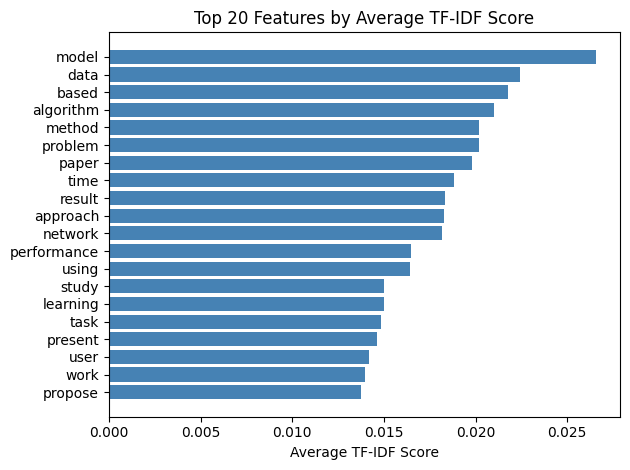

In [16]:
# Ranks features (words) by their average TF-IDF score across all training documents.
# Words with high average scores are the most informative and are retained when we restrict the vocabulary in feature selection.
def analyze_feature_importance(vectorizer, X_train_full, top_n=20):
    feature_names = vectorizer.get_feature_names_out()

    # Average TF-IDF score per word across all training documents
    avg_tfidf = X_train_full.mean(
        axis=0
    ).A1  # .A1 converts sparse matrix row to 1D array

    feature_importance = pd.DataFrame(
        {"feature": feature_names, "avg_tfidf": avg_tfidf}
    ).sort_values("avg_tfidf", ascending=False)

    print(f"Top {top_n} most important features by average TF-IDF score:")
    print(feature_importance.head(top_n).to_string(index=False))

    # Bar Chart for word labels
    top_features = feature_importance.head(top_n)
    plt.barh(
        top_features["feature"][::-1],
        top_features["avg_tfidf"][::-1],
        color="steelblue",
    )
    plt.xlabel("Average TF-IDF Score")
    plt.title(f"Top {top_n} Features by Average TF-IDF Score")
    plt.tight_layout()
    os.makedirs("../../figures", exist_ok=True)
    plt.savefig("../../figures/top_features.png", dpi=100)
    plt.show()


analyze_feature_importance(full_vectorizer, X_train_full, top_n=20)